In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

## 数据处理

In [ ]:
# 缺失值 & str格式转换
import pandas as pd
import numpy as np

input_path = PROJECT_ROOT /"dataset/icecore/chem/merged_chem.csv"
output_path = PROJECT_ROOT /"dataset/icecore/chem/merged_chem.csv"

# 读取 csv
df = pd.read_csv(input_path)

# 默认第一列是 year，其余列是降雪量
year_col = df.columns[0]
accum_cols = df.columns[1:]

# 年份列转数字
df[year_col] = pd.to_numeric(df[year_col], errors="coerce")

# 处理降雪量列
for col in accum_cols:
    # 先把字符串形式的 nan 改成真正空值
    df[col] = df[col].replace(
        ["nan", "NaN", "NAN", "Nan", "na", "NA", "N/A", ""],
        np.nan
    )

    # 再把能转换的值转成 float，不能转换的也变成空值
    df[col] = pd.to_numeric(df[col], errors="coerce")

# if input_path == "/sharedata/home/cyyang/SEMPO/dataset/icecore/accum/merged_accumulation.csv":
#     df.drop('Bruce Plateau', axis=1, inplace=True)

# 保存时 na_rep="" 表示把 NaN 写成空白格
df.to_csv(output_path, index=False, na_rep="")

print("保存完成:", output_path)
print(df.shape)
print(df.dtypes)

保存完成: /sharedata/home/cyyang/SEMPO/dataset/icecore/accum/merged_accumulation.csv
(2062, 79)
year                       int64
vrs-13 (vostok stack)    float64
B31 3.43W                float64
B32 0.00667E             float64
B33 6.4983E              float64
                          ...   
Fimbulisen s100          float64
Ekstroem B04             float64
FB9802                   float64
Derwael Ice Rise         float64
H72 41.08333E            float64
Length: 79, dtype: object


In [27]:
# 插补 & 对齐
import pandas as pd
import numpy as np

INPUT_CSV  = PROJECT_ROOT /'dataset/icecore/chem/merged_chem_renamed.csv'
YEAR_START = 1897
YEAR_END   = 1996
MISS_THRESH = 0.2

raw = pd.read_csv(INPUT_CSV)
raw = raw.sort_values('year').reset_index(drop=True)
df = raw[(raw['year'] >= YEAR_START) & (raw['year'] <= YEAR_END)].copy()
df = df.reset_index(drop=True)
total_years = len(df)
print(f'截取 {YEAR_START}~{YEAR_END}，共 {total_years} 年')

site_cols = [c for c in df.columns if c != 'year']
keep_cols = []
drop_cols = []
for col in site_cols:
    miss_rate = df[col].isna().sum() / total_years
    if miss_rate > MISS_THRESH:
        drop_cols.append((col, miss_rate))
    else:
        keep_cols.append((col, miss_rate))

print(f'\n保留站点 ({len(keep_cols)}个):')
for name, mr in keep_cols:
    short = name[:50] + '...' if len(name) > 50 else name
    print(f'  {short:55s} 缺失率={mr:.1%}')

print(f'\n删除站点 ({len(drop_cols)}个, 缺失>30%):')
for name, mr in drop_cols:
    short = name[:50] + '...' if len(name) > 50 else name
    print(f'  {short:55s} 缺失率={mr:.1%}')

keep_names = [c for c, _ in keep_cols]
df = df[['year'] + keep_names].copy()

for col in keep_names:
    if df[col].isna().any():
        n_miss_before = df[col].isna().sum()
        df[col] = df[col].interpolate(method='linear', limit_direction='both')
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
        n_miss_after = df[col].isna().sum()
        short = col[:50] + '...' if len(col) > 50 else col
        print(f'  填充 {short}: {n_miss_before} -> {n_miss_after} 缺失')

df = df.drop(columns=['Bruce Plateau', 'Fimbulisen s100', 'Law Dome (2015)', 'Rendezvous', 'Jurassic','Ferrigno', 'Gomez'])

df.to_csv(PROJECT_ROOT /"dataset/icecore/chem/chem.csv", index=False)
assert df.isna().sum().sum() == 0, '仍有缺失值！'
print(f'\n最终数据: {df.shape[0]} 年 x {df.shape[1]-1} 站点，无缺失')
print(f'年份: {int(df.year.min())} ~ {int(df.year.max())}')
print('验证通过!')

截取 1897~1996，共 100 年

保留站点 (50个):
  B33 6.4983E                                             缺失率=0.0%
  Bruce Plateau                                           缺失率=0.0%
  DIV2010_chem                                            缺失率=0.0%
  DML07                                                   缺失率=0.0%
  FB97DML05                                               缺失率=0.0%
  FB9807                                                  缺失率=0.0%
  FB9809                                                  缺失率=0.0%
  FB9814                                                  缺失率=0.0%
  Ferrigno                                                缺失率=1.0%
  Fimbulisen s100                                         缺失率=2.0%
  Gomez                                                   缺失率=0.0%
  ITASE-00-1                                              缺失率=0.0%
  ITASE-00-3_chem                                         缺失率=0.0%
  ITASE-00-4                                              缺失率=0.0%
  ITASE-00-5                

/tmp/ipykernel_982392/2329215436.py:44: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill').fillna(method='bfill')


In [18]:
df

,year,B33 6.4983E,DIV2010_chem,DML07,FB97DML05,FB9807,FB9809,FB9814,ITASE-00-1,ITASE-00-3_chem,...,SP01,SP04C5,SP04C6,SPOLE 0EW,THW2010,Talos Dome 159.07575E,UP-C,WD05A 112.125W,WDC05A,cDML
0,1897,1510.184000,4444.2770,1622.895304,1140.764198,829.260,3281.18960,2471.69799,2873.29250,11173.50491,...,595.080916,1008.254739,840.7,398.375711,5625.7866,1509.886000,5533.478062,7835.501432,4983.2172,36247.77858
1,1898,922.971600,9261.5808,1009.222922,1534.066272,641.240,781.14561,1108.48191,7722.86562,8057.13677,...,1068.944862,1108.223022,851.4,875.012665,2034.5560,1324.890000,7086.411421,7488.920670,4158.2278,36247.77858
2,1899,886.707000,15823.5687,2993.830540,1144.384638,1645.532,1392.84594,2304.95671,7206.78459,6728.99236,...,812.734028,646.392941,1006.3,752.562448,3923.8914,867.580000,1591.728768,9131.189915,279.0344,36247.77858
3,1900,1150.354800,10847.7739,1906.912418,1249.302828,1059.236,5276.09355,700.66595,6765.11724,8028.51541,...,1488.259950,839.231457,1086.2,958.442266,2807.9304,2063.092080,6525.874644,4254.026249,3014.9145,36247.77858
4,1901,893.131500,11916.7830,1322.684635,741.265908,452.268,1097.53336,1015.21710,5414.50182,6726.37120,...,464.044099,1311.355144,1035.4,717.116231,2681.8740,2100.221760,6375.180240,2885.513602,4486.2825,36247.77858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1992,1149.255835,13444.0704,1221.420649,632.991132,658.852,2145.23760,2462.34876,10725.21240,11549.32935,...,1469.593620,859.034881,652.3,1157.891058,4083.0075,2880.316667,15558.082960,7610.226078,4326.4068,29787.71264
96,1993,522.753643,9007.7715,4385.771190,1821.539880,655.316,1675.51272,750.72000,5219.06301,7557.72686,...,326.970843,304.230196,464.0,1600.706471,5141.0952,2880.316667,14807.157840,3824.373750,6097.2744,18471.43710
97,1994,1509.122473,6206.3199,5158.272413,2236.146615,624.172,1524.93751,211.84020,5926.47072,3384.21750,...,990.591185,779.448690,553.7,1249.039248,6542.5320,2880.316667,9267.241723,2901.502478,4334.3750,10332.85350
98,1995,1333.489727,10766.7522,6064.849698,5783.870216,505.376,766.06208,995.86410,6288.79500,7812.05745,...,399.815046,592.376341,412.2,391.451267,4748.5905,2880.316667,8178.767478,4124.179686,5202.8448,17522.34484


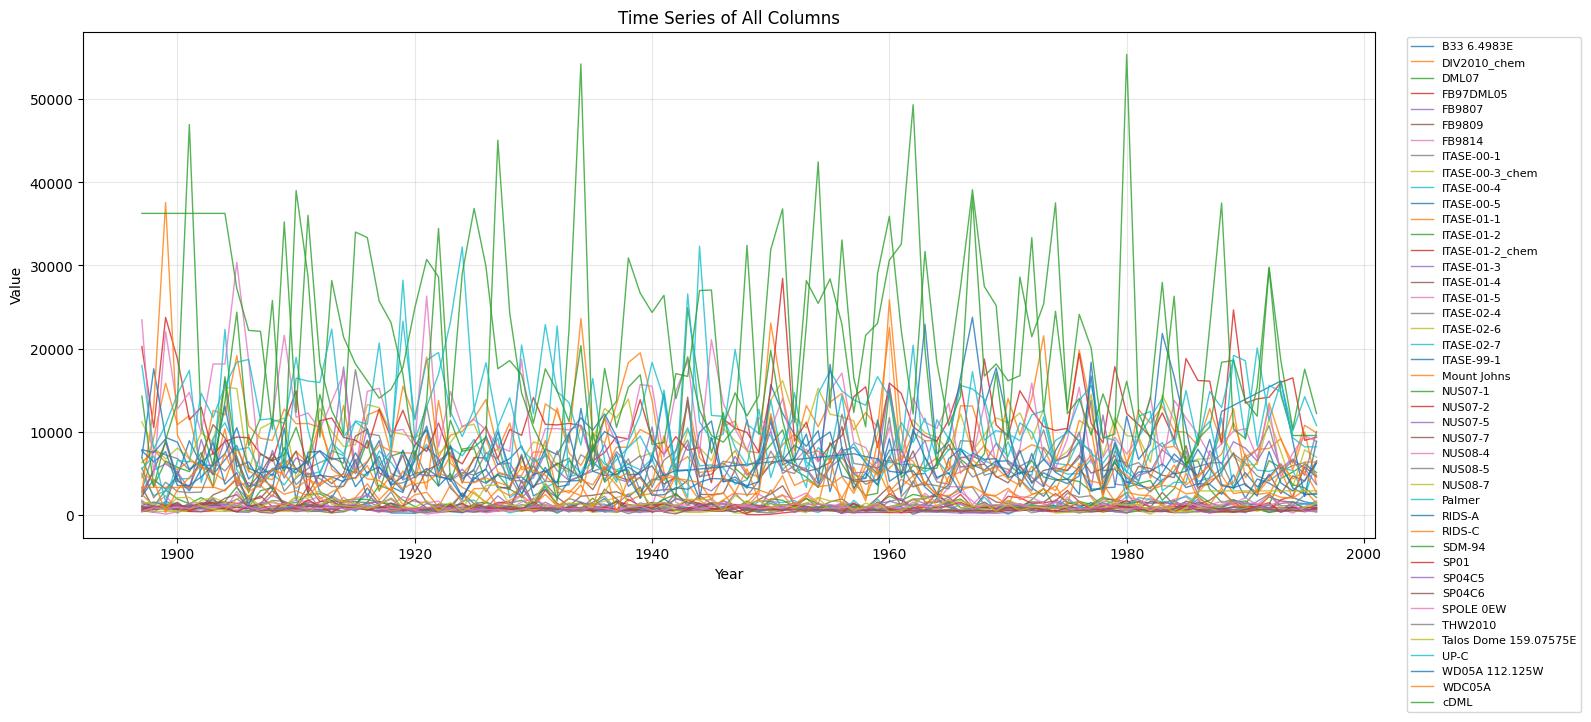

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(PROJECT_ROOT /"dataset/icecore/chem/chem.csv")

# 如果有 year 列，用 year 当横轴
if "year" in df.columns:
    df = df.set_index("year")

# 转成数值
df = df.apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(16, 7))

for col in df.columns:
    plt.plot(df.index, df[col], linewidth=1, alpha=0.8, label=col)

plt.xlabel("Year" if df.index.name == "year" else "Index")
plt.ylabel("Value")
plt.title("Time Series of All Columns")
plt.grid(alpha=0.3)

# 列太多的话 legend 会很挤，可以先注释掉
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("/sharedata/home/cyyang/SEMPO_copy/dataset/icecore/chem/chem.csv")

if "year" in df.columns:
    df = df.set_index("year")

df = df.apply(pd.to_numeric, errors="coerce")

summary = pd.DataFrame({
    "median_abs": df.abs().median(),
    "q90_abs": df.abs().quantile(0.90),
    "max_abs": df.abs().max(),
    "missing_ratio": df.isna().mean()
})

# 用所有列的 median_abs 的中位数作为基准
baseline = summary["median_abs"].replace(0, np.nan).median()

summary["median_ratio_to_global"] = summary["median_abs"] / baseline
summary["q90_ratio_to_global"] = summary["q90_abs"] / summary["q90_abs"].replace(0, np.nan).median()
summary["max_ratio_to_global"] = summary["max_abs"] / summary["max_abs"].replace(0, np.nan).median()

# 阈值可以调，比如 >10 表示数量级可能明显偏高
abnormal_cols = summary[
    (summary["median_ratio_to_global"] > 10) |
    (summary["q90_ratio_to_global"] > 10) |
    (summary["max_ratio_to_global"] > 10)
].sort_values("max_ratio_to_global", ascending=False)

print("可能数量级异常偏高的列：")
print(abnormal_cols)

print("\n所有列统计：")
print(summary.sort_values("max_abs", ascending=False))

可能数量级异常偏高的列：
                    median_abs        q90_abs       max_abs  missing_ratio  \
Fimbulisen s100  184267.900000  843991.560000  2.607738e+06            0.0   
Bruce Plateau    298100.000000  619470.000000  1.307800e+06            0.0   
Law Dome (2015)   53380.441625   80088.663900  1.296590e+05            0.0   
Rendezvous        52769.958995   90591.503075  1.274513e+05            0.0   
Jurassic          44053.780005   89466.346127  1.185665e+05            0.0   

                 median_ratio_to_global  q90_ratio_to_global  \
Fimbulisen s100               40.291260           107.888234   
Bruce Plateau                 65.181318            79.187432   
Law Dome (2015)               11.671947            10.237809   
Rendezvous                    11.538462            11.580397   
Jurassic                       9.632618            11.436567   

                 max_ratio_to_global  
Fimbulisen s100           172.111700  
Bruce Plateau              86.315284  
Law Dome (2015) 

In [24]:
import re
import pandas as pd


# =========================
# 1. 路径
# =========================

MERGED_CHEM_PATH = PROJECT_ROOT/"dataset/icecore/chem/merged_chem.csv"
OUT_PATH = PROJECT_ROOT/"dataset/icecore/chem/merged_chem_renamed.csv"


# =========================
# 2. 站点映射字典
# =========================

# A. 站点名 / 规范名可直接对应的 16 个
# 这些改成 data_sources 里的标准命名
DIRECT_SITE_MAP = {
    "105km": "105 km",
    "Bruce Plateau": "Bruce Plateau",
    "Ferrigno": "Ferrigno",
    "Gomez": "Gomez",
    "ITASE-00-1": "ITASE-00-1",
    "ITASE-00-4": "ITASE-00-4",
    "ITASE-00-5": "ITASE-00-5",
    "ITASE-01-1": "ITASE-01-1",
    "ITASE-01-3": "ITASE-01-3",
    "ITASE-01-4": "ITASE-01-4",
    "ITASE-01-5": "ITASE-01-5",
    "ITASE-02-4": "ITASE-02-4",
    "ITASE-02-7": "ITASE-02-7",
    "ITASE-99-1": "ITASE-99-1",
    "PIG2010": "PIG2010",
    "THW2010": "THW2010",
}


# B. 坐标近似同点的 27 个
# 这些也统一改成 data_sources 中的候选站点名
APPROX_SITE_MAP = {
    "DML17C98_33(B33)": "B33 6.4983E",
    "CWA_a_2013": "CWA-A",
    "CWA_d_2013": "CWA-D",
    "DML05": "FB97DML05",

    # 注意：这几个都靠近 FB9807
    # 这里按你的规则统一命名为 data_sources 候选，后面重复列取平均
    "B40": "FB9807",
    "EDML": "FB9807",
    "ISO-ICE_spa": "FB9807",
    "ISO-ICE_spb": "FB9807",

    "DML03C98_09(FB9809)": "FB9809",
    "DML15C98_14(FB9814)": "FB9814",
    "FIS_S100": "Fimbulisen s100",

    # 注意：这里 ITASE-02-1 坐标近似到 data_sources 里的 ITASE-01-2
    "ITASE-02-1": "ITASE-01-2",

    "DSS0506": "Law Dome (2015)",
    "LawDome_DSS": "Law Dome (2015)",

    "RIDS95A_2013": "RIDS-A",
    "RIDS95B_2013": "RIDS-B",
    "RIDS95C_2013": "RIDS-C",
    "SDM1994_2013": "SDM-94",

    "SPICE": "SPOLE 0EW",
    "SouthPole1995_2013": "SPOLE 0EW",

    "TD05": "Talos Dome 159.07575E",
    "UpC_2013": "UP-C",
    "WDC06A": "WD05A 112.125W",

    "BH-1": "vrs-13 (vostok stack)",
    "BH-2": "vrs-13 (vostok stack)",
    "Vostok5G_ic": "vrs-13 (vostok stack)",
    "Vostok5G_icp-ms_hplc": "vrs-13 (vostok stack)",
}


# C. 近邻疑似同点的 14 个
# 这些暂时不映射到 data_sources 候选，只保留 merged_chem 原站点名，并删除单位
NEAR_REVIEW_SITES = [
    "BER11C95_25",
    "DIR",
    "ITASE-02-6",
    "PIG",
    "SP01",
    "SP04C5",
    "SP04C6",
    "THW",
    "VKT55",
    "W10k",
    "WDC05A",
    "WDC05Q",
    "vk07",
    "vk55",
]


# D. 同名但坐标冲突的 3 个
# 这些不能覆盖 data_sources 原站点，所以作为新站点，后面加 _chem
COORD_CONFLICT_MAP = {
    "DIV2010": "DIV2010_chem",
    "ITASE-00-3": "ITASE-00-3_chem",
    "ITASE-01-2": "ITASE-01-2_chem",
}


# E. 不在 data_sources 中的 57 个
# 这些也不映射，只删除单位，保留原站点名
MISSING_SITES = [
    "ABN_13/14_snowpit",
    "Bouvet Island",
    "DF01",
    "DFS10",
    "DML07",
    "DT401",
    "EDC",
    "EDC96",
    "EDC_50y",
    "EPICA DC",
    "EPICA DomeC",
    "FIS_BI",
    "FIS_KC",
    "FIS_KM",
    "GIP ic",
    "GIP icp-ms",
    "H15",
    "IC-06",
    "ITASE-00-2",
    "ITASE-01-6",
    "ITASE-02-5",
    "ITASE-03-1",
    "ITASE-03-3",
    "Jurassic",
    "LGB69",
    "MES2012 ic",
    "MES2012 icp-ms",
    "MI0910",
    "Mount Johns",
    "NFL-1",
    "NUS07-1",
    "NUS07-2",
    "NUS07-5",
    "NUS07-7",
    "NUS08-4",
    "NUS08-5",
    "NUS08-7",
    "NVFL-1",
    "NVFL00",
    "PV-10",
    "Palmer",
    "RICE12-13pit",
    "Rendezvous",
    "SCH2",
    "SHIC",
    "SKBL",
    "SW-42",
    "SW-80",
    "TA192A__Adelie_Land",
    "TD96",
    "TaylorDome",
    "VFL-1",
    "VLG",
    "WHG ic",
    "WHG icp-ms",
    "WP",
    "cDML",
]


# 最终用于 merged_chem 重命名的总字典
# 注意：
# - 14 个近邻疑似点和 57 个缺失点不需要进字典，因为它们保留原名；
# - 但是所有列都会统一删掉单位。
SITE_RENAME_MAP = {}
SITE_RENAME_MAP.update(DIRECT_SITE_MAP)
SITE_RENAME_MAP.update(APPROX_SITE_MAP)
SITE_RENAME_MAP.update(COORD_CONFLICT_MAP)


# =========================
# 3. 工具函数
# =========================

def strip_unit_from_col(col):
    """
    merged_chem 原列名类似：
        B40 (ppb kg m-2)
    这里提取站点名：
        B40
    """
    if col == "Year CE":
        return col

    m = re.match(r"^(.*?)\s*\([^)]*\)\s*$", str(col))
    if m:
        return m.group(1).strip()

    return str(col).strip()


# =========================
# 4. 读取并重命名
# =========================

df = pd.read_csv(MERGED_CHEM_PATH)

if "Year CE" not in df.columns:
    raise ValueError("merged_chem.csv 中没有找到 'Year CE' 列。")

old_site_names = [
    strip_unit_from_col(c)
    for c in df.columns
    if c != "Year CE"
]

expected_all_sites = (
    set(DIRECT_SITE_MAP.keys())
    | set(APPROX_SITE_MAP.keys())
    | set(NEAR_REVIEW_SITES)
    | set(COORD_CONFLICT_MAP.keys())
    | set(MISSING_SITES)
)

actual_all_sites = set(old_site_names)

missing_in_rules = sorted(actual_all_sites - expected_all_sites)
extra_in_rules = sorted(expected_all_sites - actual_all_sites)

if missing_in_rules:
    raise ValueError(
        "下面这些 merged_chem 站点没有被任何规则覆盖，请检查：\n"
        + "\n".join(missing_in_rules)
    )

if extra_in_rules:
    raise ValueError(
        "规则中有这些站点，但 merged_chem 里没有找到，请检查：\n"
        + "\n".join(extra_in_rules)
    )


# 所有列去单位，并按字典重命名
new_cols = []

for col in df.columns:
    if col == "Year CE":
        new_cols.append("Year CE")
        continue

    site = strip_unit_from_col(col)
    new_site = SITE_RENAME_MAP.get(site, site)
    new_cols.append(new_site)

df.columns = new_cols


# =========================
# 5. 统一站点名后，重复列取平均
# =========================
# 例如：
# B40 / EDML / ISO-ICE_spa / ISO-ICE_spb -> FB9807
# 统一后会出现多个 FB9807 列，这里按年份逐行取平均。

site_cols = [c for c in df.columns if c != "Year CE"]

out = pd.DataFrame()
out["Year CE"] = df["Year CE"]

for site in sorted(set(site_cols)):
    same_site_df = df.loc[:, df.columns == site]

    if same_site_df.shape[1] == 1:
        out[site] = same_site_df.iloc[:, 0]
    else:
        out[site] = same_site_df.mean(axis=1, skipna=True)

out.to_csv(OUT_PATH, index=False)


# =========================
# 6. 打印检查信息
# =========================

print("原始 merged_chem 站点数:", len(old_site_names))
print("重命名后唯一站点数:", len([c for c in out.columns if c != "Year CE"]))
print("输出文件:", OUT_PATH)

print("\n重命名后出现重复并已取平均的站点：")
for site in sorted(set(site_cols)):
    n = site_cols.count(site)
    if n > 1:
        print(f"  {site}: {n} 列 -> 1 列")

原始 merged_chem 站点数: 117
重命名后唯一站点数: 109
输出文件: /sharedata/home/cyyang/SEMPO_copy/dataset/icecore/chem/merged_chem_renamed.csv

重命名后出现重复并已取平均的站点：
  FB9807: 4 列 -> 1 列
  Law Dome (2015): 2 列 -> 1 列
  SPOLE 0EW: 2 列 -> 1 列
  vrs-13 (vostok stack): 4 列 -> 1 列


/tmp/ipykernel_982392/2138957852.py:278: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[site] = same_site_df.iloc[:, 0]
/tmp/ipykernel_982392/2138957852.py:278: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[site] = same_site_df.iloc[:, 0]
/tmp/ipykernel_982392/2138957852.py:278: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 

In [25]:
# data_sources新增站点
import pandas as pd


# =========================
# 1. 路径
# =========================

DATA_SOURCES_PATH = PROJECT_ROOT/"dataset/icecore/data_sources.csv"
METADATA_PATH = PROJECT_ROOT/"dataset/icecore/chem/data_sources_chem.csv"
CLEAN_CHEM_PATH = PROJECT_ROOT/"dataset/icecore/chem/merged_chem_renamed.csv"
OUT_PATH = PROJECT_ROOT/"dataset/icecore/data_sources.csv"


# =========================
# 2. 和 merged_chem 代码保持一致的映射
# =========================

DIRECT_SITE_MAP = {
    "105km": "105 km",
    "Bruce Plateau": "Bruce Plateau",
    "Ferrigno": "Ferrigno",
    "Gomez": "Gomez",
    "ITASE-00-1": "ITASE-00-1",
    "ITASE-00-4": "ITASE-00-4",
    "ITASE-00-5": "ITASE-00-5",
    "ITASE-01-1": "ITASE-01-1",
    "ITASE-01-3": "ITASE-01-3",
    "ITASE-01-4": "ITASE-01-4",
    "ITASE-01-5": "ITASE-01-5",
    "ITASE-02-4": "ITASE-02-4",
    "ITASE-02-7": "ITASE-02-7",
    "ITASE-99-1": "ITASE-99-1",
    "PIG2010": "PIG2010",
    "THW2010": "THW2010",
}

APPROX_SITE_MAP = {
    "DML17C98_33(B33)": "B33 6.4983E",
    "CWA_a_2013": "CWA-A",
    "CWA_d_2013": "CWA-D",
    "DML05": "FB97DML05",
    "B40": "FB9807",
    "EDML": "FB9807",
    "ISO-ICE_spa": "FB9807",
    "ISO-ICE_spb": "FB9807",
    "DML03C98_09(FB9809)": "FB9809",
    "DML15C98_14(FB9814)": "FB9814",
    "FIS_S100": "Fimbulisen s100",
    "ITASE-02-1": "ITASE-01-2",
    "DSS0506": "Law Dome (2015)",
    "LawDome_DSS": "Law Dome (2015)",
    "RIDS95A_2013": "RIDS-A",
    "RIDS95B_2013": "RIDS-B",
    "RIDS95C_2013": "RIDS-C",
    "SDM1994_2013": "SDM-94",
    "SPICE": "SPOLE 0EW",
    "SouthPole1995_2013": "SPOLE 0EW",
    "TD05": "Talos Dome 159.07575E",
    "UpC_2013": "UP-C",
    "WDC06A": "WD05A 112.125W",
    "BH-1": "vrs-13 (vostok stack)",
    "BH-2": "vrs-13 (vostok stack)",
    "Vostok5G_ic": "vrs-13 (vostok stack)",
    "Vostok5G_icp-ms_hplc": "vrs-13 (vostok stack)",
}

COORD_CONFLICT_MAP = {
    "DIV2010": "DIV2010_chem",
    "ITASE-00-3": "ITASE-00-3_chem",
    "ITASE-01-2": "ITASE-01-2_chem",
}

SITE_RENAME_MAP = {}
SITE_RENAME_MAP.update(DIRECT_SITE_MAP)
SITE_RENAME_MAP.update(APPROX_SITE_MAP)
SITE_RENAME_MAP.update(COORD_CONFLICT_MAP)


# =========================
# 3. 读取文件
# =========================

data_sources = pd.read_csv(DATA_SOURCES_PATH)
metadata = pd.read_csv(METADATA_PATH, comment="#")
clean_chem = pd.read_csv(CLEAN_CHEM_PATH)


# =========================
# 4. 整理 metadata_annual
# =========================

metadata_small = metadata[
    [
        "Name",
        "Latitude (degree_north)",
        "Longitude (degree_east)",
        "Elevation (m a.s.l.)",
    ]
].copy()

metadata_small = metadata_small.rename(
    columns={
        "Name": "original_site",
        "Latitude (degree_north)": "Latitude",
        "Longitude (degree_east)": "Longitude",
        "Elevation (m a.s.l.)": "Elevation",
    }
)

for col in ["Latitude", "Longitude", "Elevation"]:
    metadata_small[col] = pd.to_numeric(metadata_small[col], errors="coerce")

for col in ["Latitude", "Longitude", "Elevation"]:
    data_sources[col] = pd.to_numeric(data_sources[col], errors="coerce")


# 给 metadata 也生成最终站点名
# 规则和 merged_chem 一致：
# - 43 个可靠对应会变成 data_sources 标准名；
# - 3 个冲突点会变成 xxx_chem；
# - 14 个近邻和 57 个缺失点保留原名。
metadata_small["site"] = metadata_small["original_site"].map(
    lambda x: SITE_RENAME_MAP.get(x, x)
)


# =========================
# 5. 找出 clean_chem 里需要 data_sources 支持的所有站点
# =========================

chem_sites = [
    c for c in clean_chem.columns
    if c != "Year CE"
]

existing_sites = set(data_sources["site"].astype(str))

sites_need_add = [
    s for s in chem_sites
    if s not in existing_sites
]


# =========================
# 6. 从 metadata 里取这些新增站点的静态特征
# =========================

to_add = metadata_small[
    metadata_small["site"].isin(sites_need_add)
][
    ["site", "Latitude", "Longitude", "Elevation"]
].copy()

# 如果多个原始站点映射到同一个最终站点，但该站点不在原 data_sources 中，
# 这里用静态特征均值。正常情况下，新增站点多数不会重复；
# 冲突点 xxx_chem 也不会重复。
to_add = (
    to_add
    .groupby("site", as_index=False)
    .agg(
        {
            "Latitude": "mean",
            "Longitude": "mean",
            "Elevation": "mean",
        }
    )
)

found_add_sites = set(to_add["site"].astype(str))
not_found = sorted(set(sites_need_add) - found_add_sites)

if not_found:
    raise ValueError(
        "下面这些 clean_chem 站点需要加入 data_sources，"
        "但在 metadata_annual 中找不到对应静态特征：\n"
        + "\n".join(not_found)
    )


# =========================
# 7. 合并并保存
# =========================

out = pd.concat(
    [data_sources, to_add],
    ignore_index=True
)

# 防止重复站点
out = (
    out
    .groupby("site", as_index=False)
    .agg(
        {
            "Latitude": "first",
            "Longitude": "first",
            "Elevation": "first",
        }
    )
)

out.to_csv(OUT_PATH, index=False)


# =========================
# 8. 打印检查信息
# =========================

print("原 data_sources 站点数:", len(data_sources))
print("clean_chem 需要的站点数:", len(chem_sites))
print("新增到 data_sources 的站点数:", len(to_add))
print("输出 data_sources 站点数:", len(out))
print("输出文件:", OUT_PATH)

print("\n新增站点列表：")
for s in sorted(to_add["site"].astype(str)):
    print("  -", s)

原 data_sources 站点数: 113
clean_chem 需要的站点数: 109
新增到 data_sources 的站点数: 43
输出 data_sources 站点数: 156
输出文件: /sharedata/home/cyyang/SEMPO_copy/dataset/icecore/data_sources.csv

新增站点列表：
  - ABN_13/14_snowpit
  - BER11C95_25
  - DF01
  - DFS10
  - DT401
  - EDC
  - EDC96
  - EDC_50y
  - EPICA DC
  - EPICA DomeC
  - FIS_BI
  - FIS_KC
  - FIS_KM
  - GIP ic
  - GIP icp-ms
  - H15
  - ITASE-02-5
  - ITASE-03-1
  - ITASE-03-3
  - LGB69
  - MES2012 ic
  - MES2012 icp-ms
  - MI0910
  - NFL-1
  - NVFL-1
  - NVFL00
  - PV-10
  - RICE12-13pit
  - SW-42
  - SW-80
  - TA192A__Adelie_Land
  - TD96
  - TaylorDome
  - VFL-1
  - VKT55
  - VLG
  - W10k
  - WDC05Q
  - WHG ic
  - WHG icp-ms
  - WP
  - vk07
  - vk55


## 变量间对比

In [1]:
import pandas as pd

df_accum = pd.read_csv('/sharedata/home/cyyang/SEMPO/dataset/icecore/accum/accum_100y.csv')
df_d18O = pd.read_csv('/sharedata/home/cyyang/SEMPO/dataset/icecore/d18O/d18O_clean.csv')
df_chem = pd.read_csv('/sharedata/home/cyyang/SEMPO/dataset/icecore/chem/chem.csv')

sites_accum = set([col for col in df_accum.columns if col.lower() != 'year'])
sites_d18O = set([col for col in df_d18O.columns if col.lower() != 'year'])
sites_chem = set([col for col in df_chem.columns if col.lower() != 'year'])

common_all = sites_accum & sites_d18O & sites_chem
common_accum_d18O = sites_accum & sites_d18O
common_accum_chem = sites_accum & sites_chem
common_d18O_chem = sites_d18O & sites_chem

print(f"--- 站点基础统计 ---")
print(f"accum.csv 站点数: {len(sites_accum)}")
print(f"d18O_clean.csv 站点数: {len(sites_d18O)}")
print(f"merged_chem_clean.csv 站点数: {len(sites_chem)}\n")

print(f"1. 三个文件共有的站点 (共 {len(common_all)} 个):")
print(sorted(list(common_all)))
print()

print(f"2. accum & d18O 共有的站点 (共 {len(common_accum_d18O)} 个):")
print(sorted(list(common_accum_d18O)))
print()

print(f"3. accum & chem 共有的站点 (共 {len(common_accum_chem)} 个):")
print(sorted(list(common_accum_chem)))
print()

print(f"4. d18O & chem 共有的站点 (共 {len(common_d18O_chem)} 个):")
print(sorted(list(common_d18O_chem)))


--- 站点基础统计 ---
accum.csv 站点数: 66
d18O_clean.csv 站点数: 19
merged_chem_clean.csv 站点数: 50

1. 三个文件共有的站点 (共 6 个):
['Fimbulisen s100', 'ITASE-00-1', 'ITASE-01-2', 'ITASE-01-5', 'ITASE-02-4', 'Law Dome (2015)']

2. accum & d18O 共有的站点 (共 15 个):
['Ekstroem B04', 'FB96DML01', 'FB97DML04', 'FB97DML06', 'FB97DML09', 'FB97DML10', 'FB9802', 'FB9813', 'Fimbulisen s100', 'Hercules Neve 165.4 E', 'ITASE-00-1', 'ITASE-01-2', 'ITASE-01-5', 'ITASE-02-4', 'Law Dome (2015)']

3. accum & chem 共有的站点 (共 24 个):
['B33 6.4983E', 'FB9807', 'FB9809', 'FB9814', 'Ferrigno', 'Fimbulisen s100', 'Gomez', 'ITASE-00-1', 'ITASE-00-4', 'ITASE-00-5', 'ITASE-01-1', 'ITASE-01-2', 'ITASE-01-3', 'ITASE-01-4', 'ITASE-01-5', 'ITASE-02-4', 'ITASE-02-7', 'ITASE-99-1', 'Law Dome (2015)', 'RIDS-A', 'RIDS-C', 'SDM-94', 'THW2010', 'UP-C']

4. d18O & chem 共有的站点 (共 8 个):
['Bruce Plateau', 'Fimbulisen s100', 'ITASE-00-1', 'ITASE-01-2', 'ITASE-01-5', 'ITASE-02-4', 'Law Dome (2015)', 'WD05A 112.125W']


## 变量间相关性

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from scipy.signal import detrend


# =========================
# 1. 读取三类变量数据
# =========================
DATA_ROOT = "/sharedata/home/cyyang/SEMPO/dataset/icecore"


def clean_site_name(name):
    """
    清理站点名，和训练 loader 的规则保持一致：
    1. 转成字符串
    2. 去掉前后空格、引号
    3. 把连续两个空格压成一个空格
    """
    return (
        str(name)
        .strip()
        .strip('"')
        .strip("'")
        .replace("  ", " ")
    )


def clean_variable_df(df):
    """
    清理变量数据表的列名。
    year 会保持为 year，其它列作为站点名清理。
    """
    return df.rename(columns={col: clean_site_name(col) for col in df.columns})


accum = clean_variable_df(
    pd.read_csv(f"/sharedata/home/cyyang/SEMPO/dataset/icecore/accum/accum_100y.csv")
).set_index("year")
d18o = clean_variable_df(
    pd.read_csv(f"/sharedata/home/cyyang/SEMPO/dataset/icecore/d18O/d18O_clean.csv")
).set_index("year")
chem = clean_variable_df(
    pd.read_csv(f"/sharedata/home/cyyang/SEMPO/dataset/icecore/chem/chem.csv")
).set_index("year")


# =========================
# 2. 读取三个聚类文件
# 每个文件需要至少包含:
# site, Level_0
# =========================
accum_cluster = pd.read_csv(f"/sharedata/home/cyyang/SEMPO/cluster/accum/accum_100y_cluster_mapped.csv")
d18o_cluster  = pd.read_csv(f"/sharedata/home/cyyang/SEMPO/cluster/d18O/d18O_cluster_mapped.csv")
chem_cluster  = pd.read_csv(f"/sharedata/home/cyyang/SEMPO/cluster/chem/chem_cluster_mapped.csv")


# =========================
# 3. 辅助函数
# =========================
def clean_cluster_df(cluster_df):
    """
    只保留 site 和 Level_0，并清理站点名。
    """
    cluster_df = cluster_df.copy()
    cluster_df["site"] = cluster_df["site"].apply(clean_site_name)
    return cluster_df[["site", "Level_0"]]


accum_cluster = clean_cluster_df(accum_cluster)
d18o_cluster  = clean_cluster_df(d18o_cluster)
chem_cluster  = clean_cluster_df(chem_cluster)


def corr_detrend_pair(s1, s2, min_len=30):
    """
    对两个时间序列：
    1. 按年份取共同非空值
    2. 线性去趋势
    3. 计算 Spearman 相关
    """
    pair = pd.concat([s1, s2], axis=1).dropna()

    if len(pair) < min_len:
        return np.nan

    x = detrend(pair.iloc[:, 0].values, type="linear")
    y = detrend(pair.iloc[:, 1].values, type="linear")

    return spearmanr(x, y)[0]


def summarize_rhos(rhos):
    """
    汇总相关系数分布。
    """
    rhos = [r for r in rhos if not np.isnan(r)]

    if len(rhos) == 0:
        return {
            "有效站点数": 0,
            "rho_mean": np.nan,
            "rho_median": np.nan,
            "abs_rho_gt_0.3_ratio": np.nan,
        }

    return {
        "有效站点数": len(rhos),
        "rho_mean": np.mean(rhos),
        "rho_median": np.median(rhos),
        "abs_rho_gt_0.3_ratio": np.mean(np.abs(rhos) > 0.3),
    }


def calc_pair_corr(v1, v2, sites, min_len=30):
    """
    给定一组站点，计算这些站点上两个变量的逐站点相关性。
    """
    rhos = []

    for site in sites:
        if site in v1.columns and site in v2.columns:
            rho = corr_detrend_pair(v1[site], v2[site], min_len=min_len)
            rhos.append(rho)

    return rhos


def analyze_total(v1, v2, name1, name2, min_len=30):
    """
    总体相关性：直接取两个变量数据表中的重合站点。
    """
    common_sites = sorted(set(v1.columns) & set(v2.columns))

    rhos = calc_pair_corr(v1, v2, common_sites, min_len=min_len)
    stat = summarize_rhos(rhos)

    return {
        "变量组合": f"{name1} ↔ {name2}",
        "范围": "总体",
        "Level_0": "All",
        "重合站点数": len(common_sites),
        **stat,
    }


def analyze_by_cluster(v1, v2, c1, c2, name1, name2, min_len=30):
    """
    分簇相关性：
    只比较两个变量中 Level_0 相同的站点。
    
    例如 accum 和 d18O：
    - accum_cluster 里 Level_0=0 的站点
    - d18O_cluster 里 Level_0=0 的站点
    - 再取二者站点交集
    """
    results = []

    common_levels = sorted(set(c1["Level_0"]) & set(c2["Level_0"]))

    for level in common_levels:
        sites1 = set(c1.loc[c1["Level_0"] == level, "site"])
        sites2 = set(c2.loc[c2["Level_0"] == level, "site"])

        same_cluster_sites = sorted(sites1 & sites2)
        same_cluster_sites = [
            s for s in same_cluster_sites
            if s in v1.columns and s in v2.columns
        ]

        rhos = calc_pair_corr(v1, v2, same_cluster_sites, min_len=min_len)
        stat = summarize_rhos(rhos)

        results.append({
            "变量组合": f"{name1} ↔ {name2}",
            "范围": "分簇",
            "Level_0": level,
            "重合站点数": len(same_cluster_sites),
            **stat,
        })

    return results


# =========================
# 4. 计算 12 个结果
# =========================
all_results = []

pairs = [
    {
        "v1": accum,
        "v2": d18o,
        "c1": accum_cluster,
        "c2": d18o_cluster,
        "name1": "accum",
        "name2": "d18O",
    },
    {
        "v1": accum,
        "v2": chem,
        "c1": accum_cluster,
        "c2": chem_cluster,
        "name1": "accum",
        "name2": "chem",
    },
    {
        "v1": d18o,
        "v2": chem,
        "c1": d18o_cluster,
        "c2": chem_cluster,
        "name1": "d18O",
        "name2": "chem",
    },
]

for item in pairs:
    # 总体
    all_results.append(
        analyze_total(
            item["v1"], item["v2"],
            item["name1"], item["name2"],
            min_len=30
        )
    )

    # 分簇
    all_results.extend(
        analyze_by_cluster(
            item["v1"], item["v2"],
            item["c1"], item["c2"],
            item["name1"], item["name2"],
            min_len=30
        )
    )


result_df = pd.DataFrame(all_results)


# =========================
# 5. 格式化输出
# =========================
result_df["rho_mean"] = result_df["rho_mean"].round(3)
result_df["rho_median"] = result_df["rho_median"].round(3)
result_df["abs_rho_gt_0.3_ratio"] = (
    result_df["abs_rho_gt_0.3_ratio"] * 100
).round(1)

result_df = result_df.rename(columns={
    "rho_mean": "ρ均值",
    "rho_median": "ρ中位数",
    "abs_rho_gt_0.3_ratio": "|ρ|>0.3比例(%)",
})

print(result_df)


# =========================
# 6. 可选：保存结果
# =========================
result_df.to_csv(
    f"{DATA_ROOT}/variable_pair_corr_by_cluster.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存到:")
print(f"{DATA_ROOT}/variable_pair_corr_by_cluster.csv")

            变量组合  范围 Level_0  重合站点数  有效站点数    ρ均值   ρ中位数  |ρ|>0.3比例(%)
0   accum ↔ d18O  总体     All     16     16  0.011 -0.020           0.0
1   accum ↔ d18O  分簇       0      2      2 -0.120 -0.120           0.0
2   accum ↔ d18O  分簇       1      7      7 -0.035 -0.040           0.0
3   accum ↔ d18O  分簇       2      2      2  0.119  0.119           0.0
4   accum ↔ chem  总体     All     23     23  0.394  0.391          73.9
5   accum ↔ chem  分簇       0      8      8  0.312  0.362          75.0
6   accum ↔ chem  分簇       1      8      8  0.446  0.545          62.5
7   accum ↔ chem  分簇       2      1      1  0.447  0.447         100.0
8    d18O ↔ chem  总体     All      5      5 -0.139 -0.068          20.0
9    d18O ↔ chem  分簇       0      0      0    NaN    NaN           NaN
10   d18O ↔ chem  分簇       1      1      1 -0.505 -0.505         100.0
11   d18O ↔ chem  分簇       2      1      1 -0.068 -0.068           0.0

已保存到:
/sharedata/home/cyyang/SEMPO/dataset/icecore/variable_pair_corr_by_clu